# تمیزکاری و مقایسه‌ی رشد قیمت — دیتاست‌های دیوار ۲۰۲۱ و ۲۰۲۳

این نوت‌بوک دو بخش باقی‌مانده از پروژه را انجام می‌دهد:
1. تمیز کردن دیتاست ۲۰۲۱ (JSON خام دیوار)
2. مقایسه‌ی رشد قیمت مناطق مختلف تهران بین ۱۴۰۰ (۲۰۲۱) و ۱۴۰۲ (۲۰۲۳)


In [1]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'DejaVu Sans'


def fa(text):
    """آماده‌سازی متن فارسی برای نمایش صحیح در matplotlib (شکل‌دهی حروف + راست‌به‌چپ)."""
    return get_display(arabic_reshaper.reshape(str(text)))


## بخش ۱: تمیزکاری دیتاست ۲۰۲۱ (JSON)

In [2]:
INPUT_2021 = "data/Divar_2021.json"
CURRENT_JALALI_YEAR_2021 = 1400

with open(INPUT_2021, encoding="utf-8") as f:
    raw_2021 = json.load(f)

print(f"تعداد کل رکوردهای خام: {len(raw_2021):,}")

# فقط آگهی‌های فروش آپارتمان مسکونی
apt_2021 = [d for d in raw_2021 if d.get("sub_category") == "apartment-sell"]
print(f"تعداد آگهی‌های فروش آپارتمان: {len(apt_2021):,}")


تعداد کل رکوردهای خام: 372,332
تعداد آگهی‌های فروش آپارتمان: 195,497


In [3]:
df21 = pd.DataFrame(apt_2021)[[
    "district", "price", "area", "year", "room", "floor", "elevator", "parking", "storage"
]].rename(columns={
    "district": "neighborhood",
    "price": "price_toman",
    "area": "area_sqm",
    "year": "build_year_jalali",
    "room": "rooms",
    "storage": "warehouse",
})

before = len(df21)
df21 = df21.dropna(subset=["price_toman", "area_sqm"])
print(f"حذف {before - len(df21):,} رکورد بدون قیمت/متراژ")

df21["price_toman"] = pd.to_numeric(df21["price_toman"], errors="coerce")
df21["area_sqm"] = pd.to_numeric(df21["area_sqm"], errors="coerce")
df21 = df21.dropna(subset=["price_toman", "area_sqm"])

before = len(df21)
df21 = df21[(df21["area_sqm"] >= 15) & (df21["area_sqm"] <= 1000) & (df21["price_toman"] > 0)]
print(f"حذف {before - len(df21):,} رکورد outlier متراژ/قیمت")

df21["price_per_sqm"] = df21["price_toman"] / df21["area_sqm"]

lower, upper = df21["price_per_sqm"].quantile([0.005, 0.995])
before = len(df21)
df21 = df21[(df21["price_per_sqm"] >= lower) & (df21["price_per_sqm"] <= upper)]
print(f"حذف {before - len(df21):,} رکورد outlier قیمت هر متر")

df21["build_year_jalali"] = pd.to_numeric(df21["build_year_jalali"], errors="coerce")
df21["building_age"] = CURRENT_JALALI_YEAR_2021 - df21["build_year_jalali"]
df21.loc[(df21["building_age"] < 0) | (df21["building_age"] > 60), "building_age"] = np.nan
df21 = df21.drop(columns=["build_year_jalali"])

for col in ["elevator", "parking", "warehouse"]:
    df21[col] = df21[col].fillna(False).astype(bool)

df21["neighborhood"] = df21["neighborhood"].astype(str).str.replace("\u200c", " ", regex=False).str.strip()
df21["year"] = 2021

df21 = df21.reset_index(drop=True)
print(f"\nتعداد نهایی رکوردهای تمیز: {len(df21):,}")
df21.head()


حذف 70,685 رکورد بدون قیمت/متراژ
حذف 143 رکورد outlier متراژ/قیمت
حذف 1,248 رکورد outlier قیمت هر متر

تعداد نهایی رکوردهای تمیز: 123,421


,neighborhood,price_toman,area_sqm,rooms,floor,elevator,parking,warehouse,price_per_sqm,building_age,year
0,نازی آباد,1.400000e+09,53.0,1.0,3.0,True,True,True,2.641509e+07,6.0,2021
1,آذربایجان,1.580000e+09,70.0,2.0,1.0,True,True,True,2.257143e+07,15.0,2021
2,آهنگ,7.000000e+08,45.0,1.0,5.0,True,False,True,1.555556e+07,18.0,2021
3,جردن,1.400000e+10,200.0,3.0,5.0,True,True,True,7.000000e+07,1.0,2021
4,شهر ری - هاشم آباد,1.630000e+09,84.0,2.0,5.0,True,True,False,1.940476e+07,6.0,2021


In [4]:
df21["price_per_sqm"].describe()

count    1.234210e+05
mean     3.516868e+07
std      2.353285e+07
min      3.722222e+06
25%      1.755556e+07
50%      3.095238e+07
75%      4.570312e+07
max      1.471698e+08
Name: price_per_sqm, dtype: float64

## بخش ۲: تمیزکاری دیتاست ۲۰۲۳ (CSV)

In [5]:
INPUT_2023 = "data/Divar_2023.csv"
CURRENT_JALALI_YEAR_2023 = 1402

PERSIAN_DIGITS = "۰۱۲۳۴۵۶۷۸۹"
ENGLISH_DIGITS = "0123456789"
DIGIT_MAP = str.maketrans(PERSIAN_DIGITS, ENGLISH_DIGITS)


def persian_price_to_number(text):
    if pd.isna(text):
        return np.nan
    text = str(text).translate(DIGIT_MAP)
    if "توافقی" in text:
        return np.nan
    digits = re.sub(r"[^\d]", "", text)
    return int(digits) if digits else np.nan


def extract_neighborhood(address):
    if pd.isna(address):
        return None
    match = re.search(r"در تهران،\s*(.+)", str(address))
    if not match:
        return None
    return match.group(1).strip().split("،")[0].strip()


df23 = pd.read_csv(INPUT_2023, encoding="utf-8", low_memory=False)
print(f"تعداد کل رکوردهای خام: {len(df23):,}")

df23["price_toman"] = df23["Price"].apply(persian_price_to_number)
for col in ["Area", "Construction", "Room"]:
    df23[col] = df23[col].astype(str).str.translate(DIGIT_MAP)
    df23[col] = pd.to_numeric(df23[col], errors="coerce")

df23["neighborhood"] = df23["Address"].apply(extract_neighborhood)

for col in ["Warehouse", "Parking", "Elevator"]:
    df23[col] = df23[col].map({"True": True, "False": False, True: True, False: False}).fillna(False)

df23 = df23.rename(columns={
    "Area": "area_sqm", "Room": "rooms",
    "Warehouse": "warehouse", "Parking": "parking", "Elevator": "elevator",
})[["neighborhood", "price_toman", "area_sqm", "Construction", "rooms", "warehouse", "parking", "elevator"]]


تعداد کل رکوردهای خام: 94,036


In [6]:
before = len(df23)
df23 = df23.dropna(subset=["price_toman", "area_sqm", "neighborhood"])
print(f"حذف {before - len(df23):,} رکورد بدون قیمت/متراژ/منطقه")

before = len(df23)
df23 = df23[(df23["area_sqm"] >= 15) & (df23["area_sqm"] <= 1000) & (df23["price_toman"] > 0)]
print(f"حذف {before - len(df23):,} رکورد outlier متراژ/قیمت")

df23["price_per_sqm"] = df23["price_toman"] / df23["area_sqm"]

lower, upper = df23["price_per_sqm"].quantile([0.005, 0.995])
before = len(df23)
df23 = df23[(df23["price_per_sqm"] >= lower) & (df23["price_per_sqm"] <= upper)]
print(f"حذف {before - len(df23):,} رکورد outlier قیمت هر متر")

df23["building_age"] = CURRENT_JALALI_YEAR_2023 - df23["Construction"]
df23.loc[(df23["building_age"] < 0) | (df23["building_age"] > 60), "building_age"] = np.nan
df23 = df23.drop(columns=["Construction"])

df23["neighborhood"] = df23["neighborhood"].str.replace("\u200c", " ", regex=False).str.strip()
df23["year"] = 2023
df23 = df23.reset_index(drop=True)

print(f"\nتعداد نهایی رکوردهای تمیز: {len(df23):,}")
df23.head()


حذف 246 رکورد بدون قیمت/متراژ/منطقه
حذف 168 رکورد outlier متراژ/قیمت
حذف 938 رکورد outlier قیمت هر متر

تعداد نهایی رکوردهای تمیز: 92,684


,neighborhood,price_toman,area_sqm,rooms,warehouse,parking,elevator,price_per_sqm,building_age,year
0,درکه,1.836000e+10,153.0,3.0,True,True,True,1.200000e+08,9.0,2023
1,زعفرانیه,1.300000e+11,418.0,4.0,True,True,True,3.110048e+08,20.0,2023
2,جابری,2.600000e+09,57.0,2.0,False,False,True,4.561404e+07,17.0,2023
3,فرمانیه,2.300000e+10,193.0,3.0,False,False,True,1.191710e+08,31.0,2023
4,دهکده المپیک,1.410000e+09,62.0,1.0,True,True,True,2.274194e+07,1.0,2023


In [7]:
df23["price_per_sqm"].describe()

count    9.268400e+04
mean     9.560176e+07
std      4.897734e+07
min      1.250000e+07
25%      6.100000e+07
50%      8.823529e+07
75%      1.183673e+08
max      3.343949e+08
Name: price_per_sqm, dtype: float64

## بخش ۳: ذخیره‌ی دیتاست‌های تمیز‌شده

In [8]:
df21.to_csv("data/divar_2021_clean.csv", index=False, encoding="utf-8-sig")
df23.to_csv("data/divar_2023_clean.csv", index=False, encoding="utf-8-sig")
print("ذخیره شد.")


ذخیره شد.


## بخش ۴: مقایسه‌ی رشد قیمت مناطق (۱۴۰۰ → ۱۴۰۲)

برای هر منطقه‌ای که در هر دو سال حداقل ۱۵ آگهی داشته باشد،
میانه‌ی قیمت هر متر مربع محاسبه و درصد رشد آن نسبت به ۲۰۲۱ بدست می‌آید.


In [9]:
MIN_LISTINGS = 15

agg21 = df21.groupby("neighborhood")["price_per_sqm"].agg(["mean", "median", "count"]).rename(columns=lambda c: f"{c}_2021")
agg23 = df23.groupby("neighborhood")["price_per_sqm"].agg(["mean", "median", "count"]).rename(columns=lambda c: f"{c}_2023")

growth = agg21.join(agg23, how="inner")
growth = growth[(growth["count_2021"] >= MIN_LISTINGS) & (growth["count_2023"] >= MIN_LISTINGS)].copy()
growth["growth_pct"] = (growth["median_2023"] - growth["median_2021"]) / growth["median_2021"] * 100
growth = growth.sort_values("growth_pct", ascending=False)

print(f"تعداد مناطق قابل مقایسه: {len(growth)}")
print(f"میانه‌ی رشد قیمت کل تهران: {growth['growth_pct'].median():.1f}٪")

growth.to_csv("data/neighborhood_growth.csv", encoding="utf-8-sig")
growth.head(10)


تعداد مناطق قابل مقایسه: 277
میانه‌ی رشد قیمت کل تهران: 145.9٪


,mean_2021,median_2021,count_2021,mean_2023,median_2023,count_2023,growth_pct
neighborhood,,,,,,,
ابن بابویه,1.563916e+07,1.497126e+07,26,4.687932e+07,4.615385e+07,23,208.282888
مولوی,1.086062e+07,1.097619e+07,220,3.343956e+07,3.371795e+07,89,207.191724
شهرک کوهسار,3.284353e+07,3.130778e+07,24,8.889089e+07,9.454545e+07,43,201.987081
زاهد گیلانی,1.947676e+07,1.825308e+07,28,5.691221e+07,5.465116e+07,15,199.407904
هفت چنار,1.789428e+07,1.715633e+07,116,5.074945e+07,5.119048e+07,209,198.376538
سلامت,1.620122e+07,1.642797e+07,46,4.859051e+07,4.881019e+07,36,197.116454
سلیمانی,1.775190e+07,1.653168e+07,154,4.871001e+07,4.854007e+07,214,193.618583
امامزاده حسن(ع),1.744063e+07,1.482846e+07,92,4.340992e+07,4.310345e+07,117,190.680544
سلسبیل,1.948154e+07,1.911111e+07,1405,5.583595e+07,5.542857e+07,1459,190.033223


### ۱۵ منطقه با بیشترین رشد قیمت

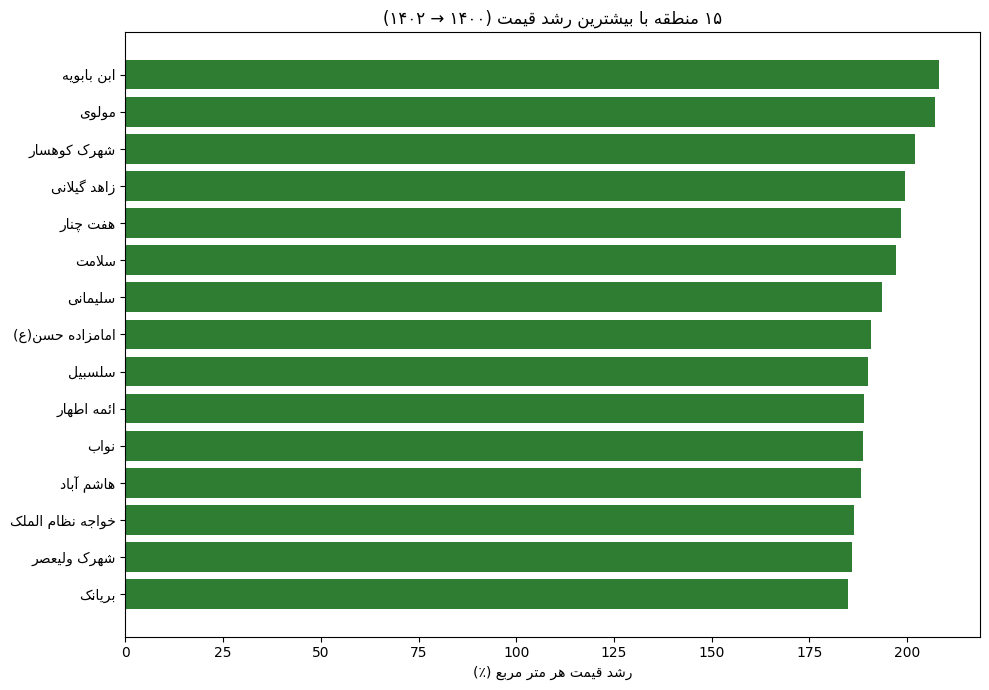

In [10]:
top15 = growth.head(15).sort_values("growth_pct")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh([fa(n) for n in top15.index], top15["growth_pct"], color="#2e7d32")
ax.set_xlabel(fa("رشد قیمت هر متر مربع (٪)"))
ax.set_title(fa("۱۵ منطقه با بیشترین رشد قیمت (۱۴۰۰ → ۱۴۰۲)"))
plt.tight_layout()
plt.savefig("data/top_growth_neighborhoods.png", dpi=150)
plt.show()


### ۱۵ منطقه با کمترین رشد قیمت

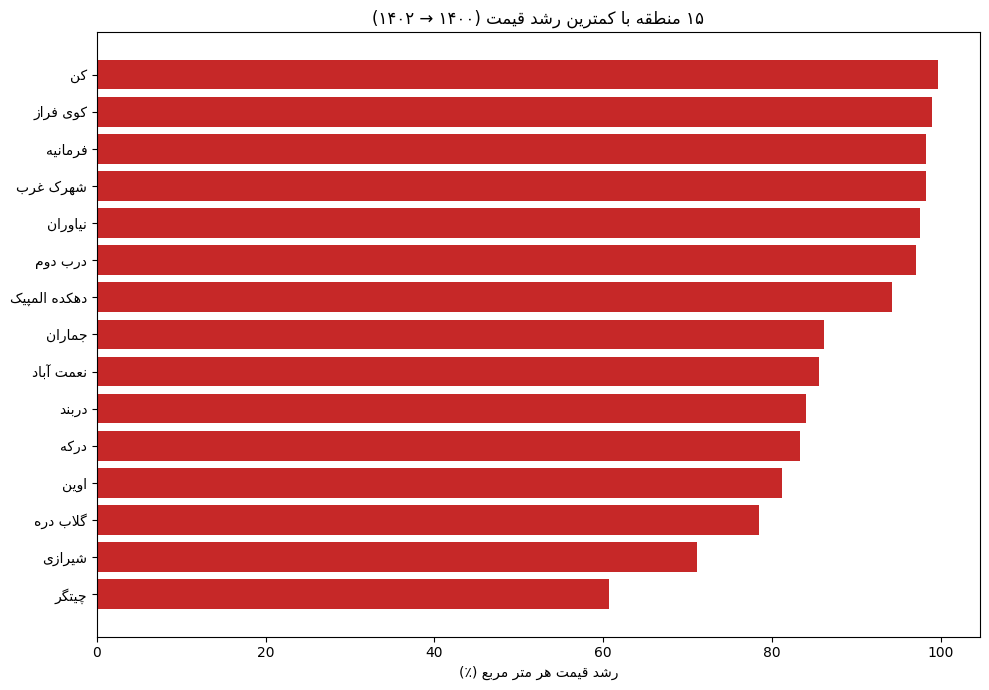

In [11]:
bottom15 = growth.tail(15).sort_values("growth_pct")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh([fa(n) for n in bottom15.index], bottom15["growth_pct"], color="#c62828")
ax.set_xlabel(fa("رشد قیمت هر متر مربع (٪)"))
ax.set_title(fa("۱۵ منطقه با کمترین رشد قیمت (۱۴۰۰ → ۱۴۰۲)"))
plt.tight_layout()
plt.savefig("data/bottom_growth_neighborhoods.png", dpi=150)
plt.show()


## جمع‌بندی

- تعداد مناطق قابل مقایسه بین دو سال، رشد قیمت هر متر مربع را نشان می‌دهد.
- مناطقی با کمترین تعداد آگهی از تحلیل کنار گذاشته شدند تا میانگین‌ها قابل اتکا باشند.
- گام بعدی: بررسی رابطه‌ی رشد قیمت با فاصله از مرکز شهر یا شاخص‌های دیگر (اختیاری).